In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# I) Data Collection

In [2]:
df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


## Difference btw EDA & Feature Engineering
EDA = “What is inside my data?”


Feature Engineering = “How can I improve my data for ML?”

# II) Performing Exploratory Data Analysis (EDA)

In [3]:
# Before Encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.describe()
# give info ONLY about Numerical columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Target Variable Distribution

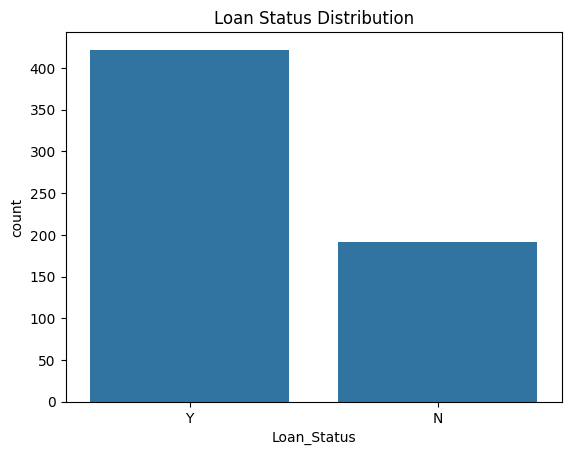

In [5]:
sns.countplot(x='Loan_Status', data=df) # countplot' mainly used to analyze CATEGORICAL DATA
plt.title("Loan Status Distribution")
plt.show()

Slight imbalance

Majority loans approved

### Credit History v/s Loan_Status

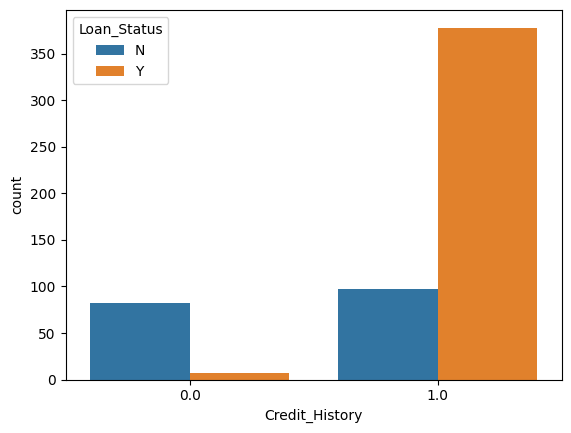

In [6]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df) # 'countplot' mainly used to analyze CATEGORICAL DATA
plt.show()

Credit_History being one of the most imp factor for prediction

Applicants with Credit_History = 1 mostly approved

In left it shows, even with Credit_History 0.0, some loans are still approved(represented with ORANGE bar), while

In right side, even with Credit_History 1.0, some loans are still rejected(represented with BLUE bar)


### Income Distribution
Applicant Income can help determine whether the person is capable to pay the loan or not

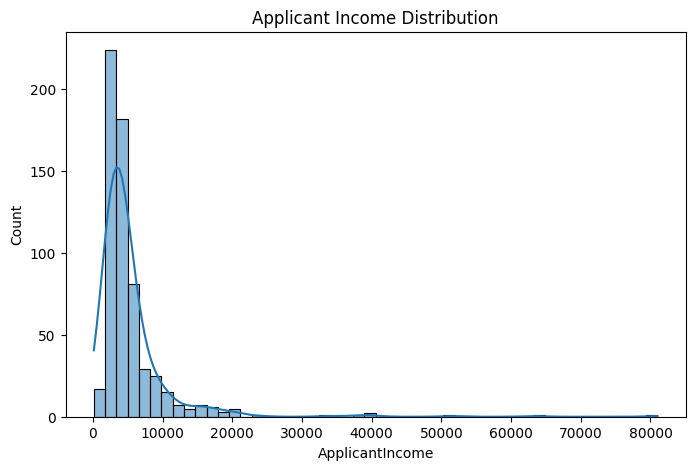

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], kde=True) # 'histplot' Mainly used for NUMERICAL DATA, a column v/s no. of rows
plt.title("Applicant Income Distribution")
plt.show()

## Correlation Heatmap
Correlation measures how two variables move together. (For NUMERICALS columns)

1) +1 → Perfect positive correlation (both increase together)
2) -1 → Perfect negative correlation (one increases, other decreases)
3) 0 → No relationship

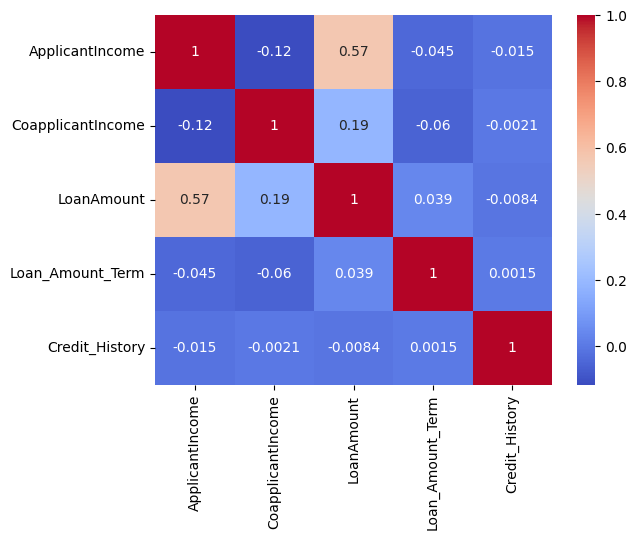

In [8]:
# To be seen Before Encoding, else CATEGORICAL columns changed to NUMERICAL will also be seen in this Correlation Heatmap
df_numeric = df.select_dtypes(include=np.number)
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

From above Correlation Heatmap, when we check for Credit_History V/S LoanAmount , the value is -0.0084; anegative value shows as the LoanAmount increases, the Credit_History gets poor

### FEATURE ENGINEERING

# III) Basic Data Cleaning

### Before Data Cleaning

In [9]:
df.shape
# gives (no. of rows, no. of cols)

(614, 13)

In [10]:
df.size
# no. of rows * no. of cols = total no. of elements present

7982

## 1) Removing Duplicate rows

In [11]:
print(df.duplicated().sum())

0


If O/P sum = 0, means dataset contains no duplicate data.

But if it contained duplicated data then do --> df.drop_duplicates(inplace=True)

## 2) Removing unnecessary columns

In [12]:
df.drop("Loan_ID", axis=1, inplace=True)
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


## 3) Creating new columns

In [13]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

In [14]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,NaN,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


# IV) Test-Train Split

In [15]:
x = df.drop('Loan_Status', axis=1) # I/P data
y = df['Loan_Status'] # O/P data

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (614, 10)
Shape of y: (614,)


In [16]:
x.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [18]:
x_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
83,Male,Yes,0,Graduate,No,265.0,360.0,NaN,Semiurban,8250.0
90,Male,Yes,0,Graduate,No,131.0,360.0,1.0,Semiurban,5858.0


In [19]:
x_test.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
350,Male,Yes,0,Graduate,No,228.0,360.0,1.0,Semiurban,9083.0
377,Male,Yes,0,Graduate,No,130.0,360.0,NaN,Semiurban,4310.0


In [20]:
y_train.head(2)

83    N
90    Y
Name: Loan_Status, dtype: str

In [21]:
y_test.head(2)

350    Y
377    Y
Name: Loan_Status, dtype: str

In [22]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape) # O/P: (491,) --> no value after ','  , coz y_train and y_test are 'Series', not 'DataFrame'
print("y_test shape:", y_test.shape) # 0.2 * 614 --> 123, so 113 data rows gone for 'Testing'

x_train shape: (491, 10)
x_test shape: (123, 10)
y_train shape: (491,)
y_test shape: (123,)


### FEATURE ENGINEERING

## 1) HANDLING MISSING / NULL VALUES

ML Algos can't work on missing values, coz ML models uses mathematical formulae which can't work on NULL values.
So, either rows containing missing values should be removed OR the NULL values must be filled with either MEAN, or MEDIAN, or MODE

#### NOTE: Handle missing values using statistics learned from TRAINING data

In [23]:
x_train.isnull().sum()

Gender              12
Married              1
Dependents          11
Education            0
Self_Employed       24
LoanAmount          16
Loan_Amount_Term    12
Credit_History      40
Property_Area        0
Total_Income         0
dtype: int64

From the above info. about no. of Null values in each column, we cannot make out which column to be kept, and which column to be dropped.
    
If a column contains more than 50% Null values, then it is better to drop that column(if not imp.), instead of filling it with Mean or Meadian or Mode.

So, we need to find the percentage of Null values for each column.

In [24]:
# Percentage of Null values in each column
# Percentage of given object = (total no. of those objects / total no. of objects) * 100

(x_train.isnull().sum() / x_train.shape[0]) * 100

# df.shape[0], gives the total no. of rows in our dataset

Gender              2.443992
Married             0.203666
Dependents          2.240326
Education           0.000000
Self_Employed       4.887984
LoanAmount          3.258656
Loan_Amount_Term    2.443992
Credit_History      8.146640
Property_Area       0.000000
Total_Income        0.000000
dtype: float64

In [25]:
# Total Null values present
x_train.isnull().sum().sum()

np.int64(116)

In [26]:
# Percentage of Total Null values in the overall dataset
(x_train.isnull().sum().sum() / x_train.size) * 100

np.float64(2.3625254582484727)

## Graphical Representation of Null values present

<Axes: >

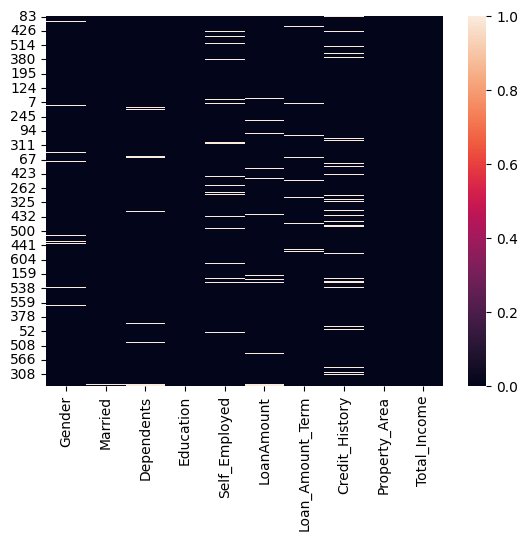

In [27]:
sns.heatmap(x_train.isnull())

In above heatmap,

0.0 --> represents False (i.e. here, Null values NOT present, represented by dark color)

1.0 --> represents True (i.e. here, Null values present, represented by white color)

#### Do not use the dataset if its overall percentage of Null values is more than 50%
Here, it is just 1%, so we can use the dataset to train the model

________________________________________________________________________________________________________________________________________________________

# Filling Null values in columns using Mean or Median or Mode
Filling the missing values in numerical or categorical

⚫ For Numerical data --> mean , meadian
1) normally distributed value --> use mean
2) not normally(i.e. skewed) distributed value --> use median

⚫ For Categorical data --> mode, backward filling, forward filling
1) backward filling --> df = df.fillna(method="bfill") --> data of below row filled in above row
2) forward filling --> df = df.fillna(method="ffill") --> data of above row filled in below row
3) mode (best)

In [28]:
x_train.isnull().sum()

Gender              12
Married              1
Dependents          11
Education            0
Self_Employed       24
LoanAmount          16
Loan_Amount_Term    12
Credit_History      40
Property_Area        0
Total_Income         0
dtype: int64

Use:

Mean → clean, balanced data

Median → skewed data or outliers

Interpretation:  
If SKEW VALUE is:

Around 0 → data is symmetric → use Mean

Greater than +1 or less than −1 → highly skewed → use Median

In [29]:
# check skew value:
x_train['LoanAmount'].skew()

np.float64(2.6112842614330396)

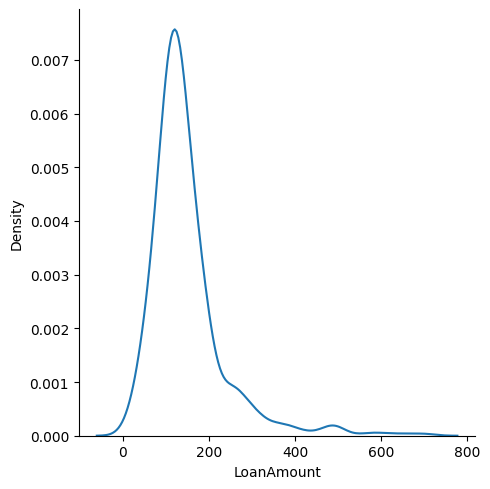

In [30]:
sns.displot(x_train['LoanAmount'], kind="kde")

<Axes: >

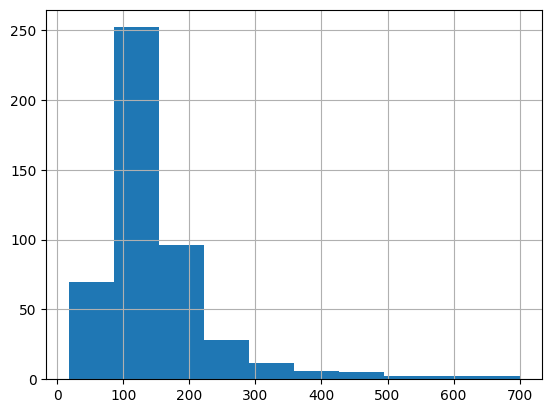

In [31]:
x_train['LoanAmount'].hist()

Data for LoanAmount is +vely skewed (also we can see skew value --> (2.67) > (+1)) , so use Median

In [32]:
# Filling all the Categorical columns with their Mode
for col in x_train.select_dtypes(include=['object']).columns:
    most_freq = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(most_freq)
    x_test[col] = x_test[col].fillna(most_freq)

C:\Users\user\AppData\Local\Temp\ipykernel_288\2942858963.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in x_train.select_dtypes(include=['object']).columns:


In [33]:
# Filling all the Numerical columns with their Mode
x_train['LoanAmount'] = x_train['LoanAmount'].fillna(x_train['LoanAmount'].median())
x_test['LoanAmount'] = x_test['LoanAmount'].fillna(x_train['LoanAmount'].median())

x_train['Loan_Amount_Term'] = x_train['Loan_Amount_Term'].fillna(x_train['Loan_Amount_Term'].mode()[0])
x_test['Loan_Amount_Term'] = x_test['Loan_Amount_Term'].fillna(x_train['Loan_Amount_Term'].mode()[0])

x_train['Credit_History'] = x_train['Credit_History'].fillna(x_train['Credit_History'].mode()[0])
x_test['Credit_History'] = x_test['Credit_History'].fillna(x_train['Credit_History'].mode()[0])

In [34]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 491 entries, 83 to 102
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            491 non-null    str    
 1   Married           491 non-null    str    
 2   Dependents        491 non-null    str    
 3   Education         491 non-null    str    
 4   Self_Employed     491 non-null    str    
 5   LoanAmount        491 non-null    float64
 6   Loan_Amount_Term  491 non-null    float64
 7   Credit_History    491 non-null    float64
 8   Property_Area     491 non-null    str    
 9   Total_Income      491 non-null    float64
dtypes: float64(4), str(6)
memory usage: 54.6 KB


We used SimpleImputer() from sklearn lib. It also help to directly fill values at the time of DEPLOYMENT, 
if not I/P by the user.

### After Data Cleaning

In [35]:
x_train.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Total_Income        0
dtype: int64

In [36]:
x_test.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Total_Income        0
dtype: int64

## 2) HANDLING OUTLIERS

### Checking for Outliers

In [37]:
# There can be outliers in Total_Income, LoanAmount, Loan_Amount_Term

### Before Handling outliers

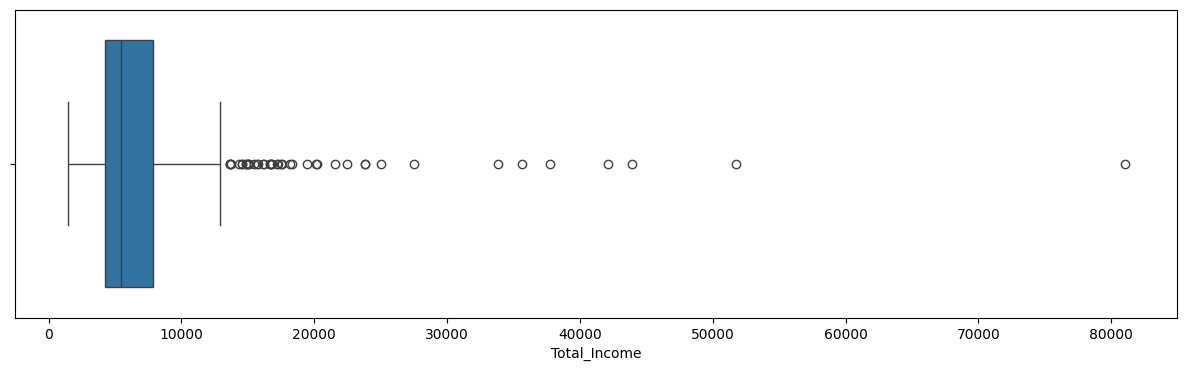

In [38]:
# Checking outliers through boxplot
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = x_train)
plt.show()

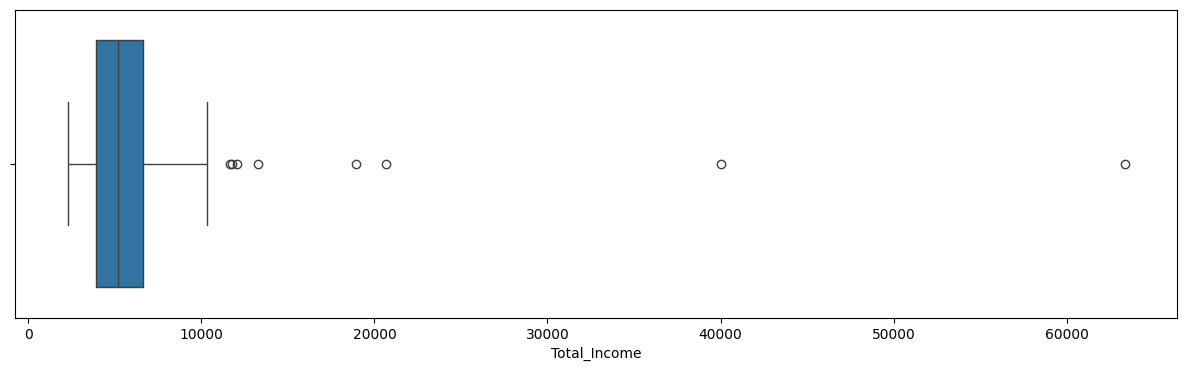

In [39]:
# Checking outliers through boxplot
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = x_test)
plt.show()

In [40]:
# We can see that 'Outliers' start from approx. 12500 ....

C:\Users\user\AppData\Local\Temp\ipykernel_288\945911088.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_288\945911088.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])


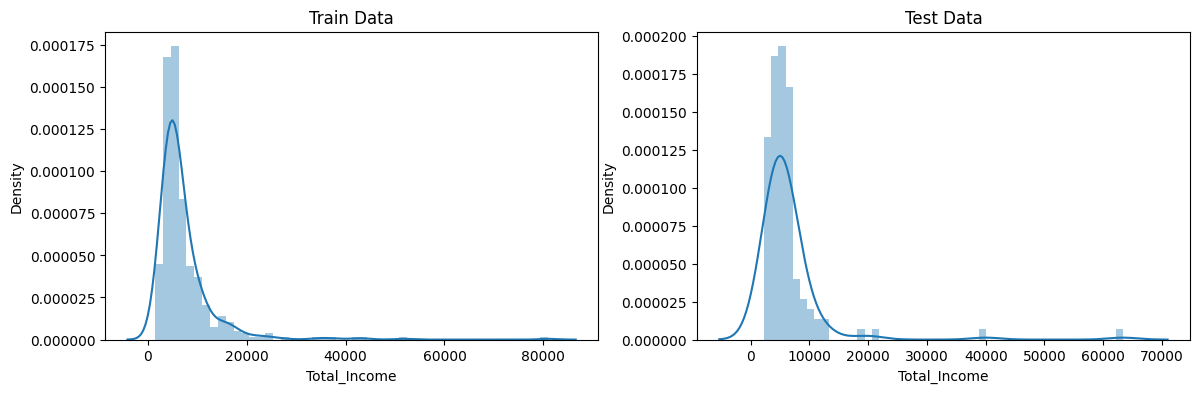

In [41]:
# Analyzing outliers through Distribution plot
plt.figure(figsize=(14, 4))

# After Outlier Removal
plt.subplot(1,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Train Data")
sns.distplot(x_train["Total_Income"])

# After Outlier Removal
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Test Data")
sns.distplot(x_test["Total_Income"])

plt.show()

In [42]:
# We can observe that the tail of the graph goes too long, means there are outliers present!!!

#### Outlier removal using IQR (Inter Quantile Range)

In [43]:
x_train.shape # has 491 rows

(491, 10)

In [44]:
q1 = x_train["Total_Income"].quantile(0.25)
q3 = x_train["Total_Income"].quantile(0.75)
IQR = q3 - q1
IQR

np.float64(3614.5)

In [45]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-1195.25), np.float64(13262.75))

In [46]:
# Here above, 'min_range' comes in -ve, and our dataset 'Total_Income' do not contain anything in -ve, 
# so we can discard 'min_range' value. Also we can see there is no outlier in the left side.

### Removing outliers from original data set

In [47]:
# We will accept those data which have less income than 'max_range' income
x_train = x_train[(x_train["Total_Income"] >= min_range) & (x_train["Total_Income"] <= max_range)]
x_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
83,Male,Yes,0,Graduate,No,265.0,360.0,1.0,Semiurban,8250.0
90,Male,Yes,0,Graduate,No,131.0,360.0,1.0,Semiurban,5858.0


In [48]:
x_train.shape # 448 rows

(448, 10)

In [49]:
# so, after removing outliers, No. of rows removed = 491 - 448 = 43 rows removed

### Applying same boundaries for 'test_dataset'

In [50]:
x_test = x_test[x_test["Total_Income"] <= max_range]

In [51]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 448 entries, 83 to 435
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            448 non-null    str    
 1   Married           448 non-null    str    
 2   Dependents        448 non-null    str    
 3   Education         448 non-null    str    
 4   Self_Employed     448 non-null    str    
 5   LoanAmount        448 non-null    float64
 6   Loan_Amount_Term  448 non-null    float64
 7   Credit_History    448 non-null    float64
 8   Property_Area     448 non-null    str    
 9   Total_Income      448 non-null    float64
dtypes: float64(4), str(6)
memory usage: 50.1 KB


In [52]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 119 entries, 350 to 11
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            119 non-null    str    
 1   Married           119 non-null    str    
 2   Dependents        119 non-null    str    
 3   Education         119 non-null    str    
 4   Self_Employed     119 non-null    str    
 5   LoanAmount        119 non-null    float64
 6   Loan_Amount_Term  119 non-null    float64
 7   Credit_History    119 non-null    float64
 8   Property_Area     119 non-null    str    
 9   Total_Income      119 non-null    float64
dtypes: float64(4), str(6)
memory usage: 13.3 KB


### After Handling outliers using IQR

C:\Users\user\AppData\Local\Temp\ipykernel_288\2049116089.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_288\2049116089.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])


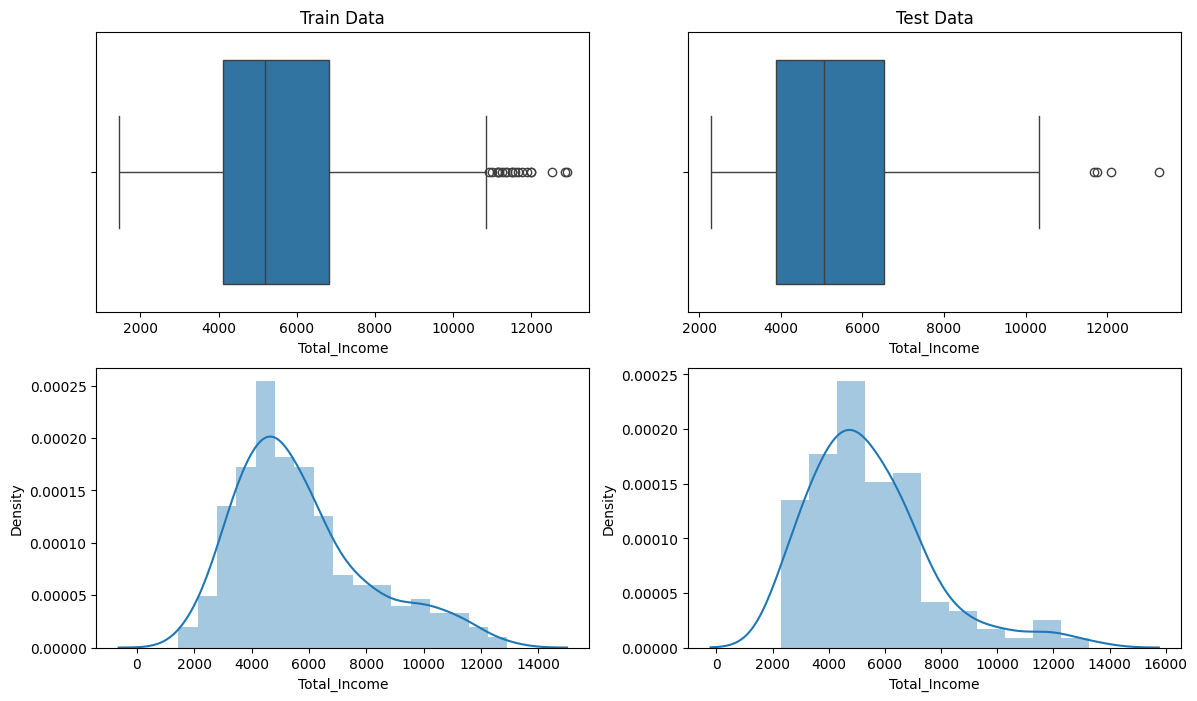

In [53]:
plt.figure(figsize=(14, 8))

# Checking outliers through boxplot
plt.subplot(2,2,1)
plt.title("Train Data")
sns.boxplot(x = 'Total_Income', data = x_train)

# Checking outliers through boxplot
plt.subplot(2,2,2)
plt.title("Test Data")
sns.boxplot(x = 'Total_Income', data = x_test)

# Before Outlier Removal for 'x_train'
plt.subplot(2,2,3) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
sns.distplot(x_train["Total_Income"])

# Before Outlier Removal for 'x_test'
plt.subplot(2,2,4) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
sns.distplot(x_test["Total_Income"])

plt.show()

In [54]:
# STILL there are some outliers left

##### NOTE: Algos. like DECISION TREE does not depend on the presence of outliers, so, NO need to remove outliers for such algos.
Becoz, removal of Outliers also leads to data loss.
##### But,  Algos. like LINEAR REGRESSION are highly affected by the presence of outliers, so, we NEED to remove outliers for such algos.

## 3) FUNCTION TRANSFORMATION

For this loan.csv dataset, columns like:

LoanAmount, Total_Income

are usually skewed, so log transformation works well.

##### Benefits:
1) Handles skewed data
2) Reduces effect of large values
3) Avoids error when value = 0

In [55]:
from sklearn.preprocessing import FunctionTransformer

In [56]:
# Create transformer
log_transformer = FunctionTransformer(np.log1p)

# Apply on train and test
x_train['LoanAmount'] = log_transformer.fit_transform(x_train[['LoanAmount']])
x_test['LoanAmount'] = log_transformer.transform(x_test[['LoanAmount']])

C:\Users\user\AppData\Local\Temp\ipykernel_288\2609822188.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_288\2609822188.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])


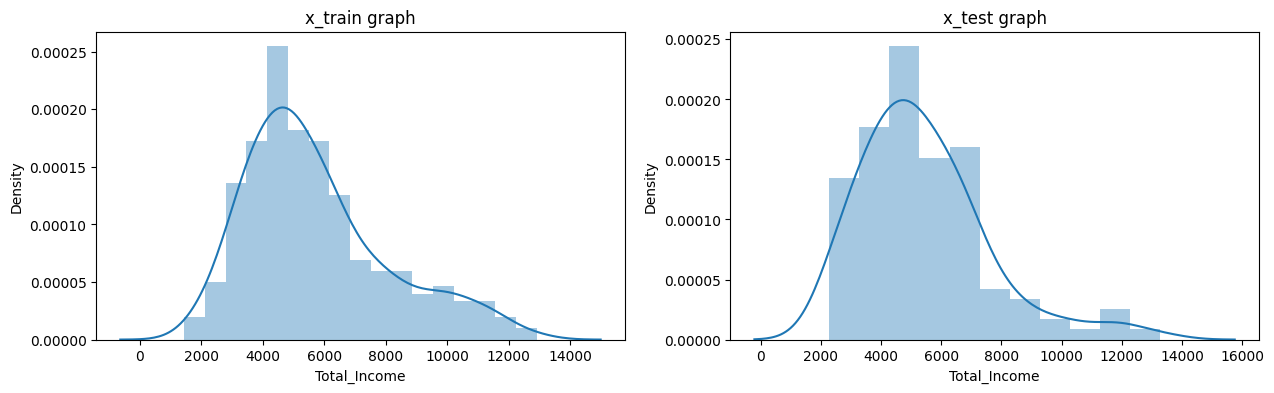

In [57]:
plt.figure(figsize=(15, 4))

# After Using FunctionTransformer on 'Total_Income' for 'x_test'
plt.subplot(1,2,1)
plt.title("x_train graph")
sns.distplot(x_train["Total_Income"])

# After Using FunctionTransformer on 'Total_Income' for 'x_test'
plt.subplot(1,2,2)
plt.title("x_test graph")
sns.distplot(x_test["Total_Income"])

plt.show()

In [58]:
# On applying 'Function Transformation' on 'LoanAmount' & 'Loan_Amount_Term', the 'tail' of the graph became longer (creating outlier type scene),
# so better not to apply 'Function Transformation' on 'LoanAmount' & 'Loan_Amount_Term'

#### NOTE:
When we know that removing OUTLIER can remove an important 'Feature' or 'Row for prediction,
then we can use the 'FunctionTransformer' without removing the outlier, and the graph would come as Normal Distribution curve

## 4) CATEGORICAL ENCODING
Converting categorical data to Numeric data, coz ML models work on Mathematical formulae & can be applied to nos. only

In [59]:
# Converting categorical to Numerical format: 
# in Ml - columns are variables - (numerical(continuous, discrete), categorical(ordinal, nominal))
# ordinal define order, nominal do not define order
# ordinal encoding and label encoding: to convert ordinal categorical into numerical
# nominal categorical variable we use- one hot encoder or dummy variable

Ordinal categorical data → Ordinal Encoding (E.g. here, Dependents --> (0, 1, 2, 3+))

Nominal categorical feature → One-Hot Encoding (E.g. here, "Gender", "Married", "Education", "Self_Employed", "Property_Area")

NOTE: "Property_Area" creates too many columns when using 'OneHotEncoder', so we may apply 'LabelEncoder' for "Property_Area" if using tree-based models like RandomForest, DecisionTree, etc., coz because 'LabelEncoder' creates ORDER, so trees split categories differently and are less affected by numeric order. 
But do not use 'LabelEncoder' for models like Logistic Regression, K-Nearest Neighbors, Support Vector Machine.
Since, here we are testing which model fits the best, so all kinds of models are used, so here better to apply 'OneHotEncoder' for 

Target variable → Label Encoding often used (E.g. here, Loan_Status)

So at the time of TESTING THE MODELS, use:

Ordinal categorical data → Ordinal Encoding

Nominal categorical feature → One-Hot Encoding

Target variable → Label Encoding often used 

## Step 1: Define column groups

In [60]:
ordinal_col = ['Dependents']
onehot_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

## Step 2: Apply Ordinal Encoding to Dependents

In [61]:
# For Dependents, preserve the order:

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=[['0', '1', '2', '3+']])

# Apply encoder
x_train[['Dependents']] = ordinal_encoder.fit_transform(x_train[['Dependents']])
x_test[['Dependents']] = ordinal_encoder.transform(x_test[['Dependents']])

## Step 3: Apply One-Hot Encoding to remaining categorical columns

In [62]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# NOT DIRECTLY UPDATING TEST-TRAIN DATASET, FIRST STORING THE THINGS IN 'encoded_train' & 'encoded_test'
encoded_train = onehot_encoder.fit_transform(x_train[onehot_cols])
encoded_test = onehot_encoder.transform(x_test[onehot_cols])

## Step 4: Convert encoded output to DataFrame

In [63]:
encoded_cols = onehot_encoder.get_feature_names_out(onehot_cols)

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoded_cols,
    index=x_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoded_cols,
    index=x_test.index
)

## Step 5: Drop original one-hot columns and combine

In [64]:
x_train = pd.concat([
    x_train.drop(columns=onehot_cols),
    encoded_train_df
], axis=1)

x_test = pd.concat([
    x_test.drop(columns=onehot_cols),
    encoded_test_df
], axis=1)

## Step 6: Apply Label Encoder on target column

In [65]:
# Target is Loan_Status, which is stored in y_train & y_test
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

## Checking the Encoding done

In [66]:
x_train.head(2)

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
83,0.0,5.583496,360.0,1.0,8250.0,1.0,1.0,0.0,0.0,1.0,0.0
90,0.0,4.882802,360.0,1.0,5858.0,1.0,1.0,0.0,0.0,1.0,0.0


In [67]:
x_test.head(2)

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
350,0.0,5.433722,360.0,1.0,9083.0,1.0,1.0,0.0,0.0,1.0,0.0
377,0.0,4.875197,360.0,1.0,4310.0,1.0,1.0,0.0,0.0,1.0,0.0


## 5) FEATURE SCALING

Scaling is done to bring all numerical features to the same range, so that no feature dominates others during model training.

And it is done after splitting(Test-Train split) to prevent data leakage.

E.g. If we have 2 apples, one of a bigger size and the other of the smaller size; we know both have same material internally, but still we prefer the bigger apple to buy, as we consider it of more importance. Similar is in the case of a ML model.

In [68]:
numeric_cols = ['LoanAmount', 'Loan_Amount_Term', 'Total_Income']

In [69]:
# Apply scaling on Numeric data(generally I/P data) only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

C:\Users\user\AppData\Local\Temp\ipykernel_288\4107479220.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_288\4107479220.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])
C:\Users\user\AppData\Loca

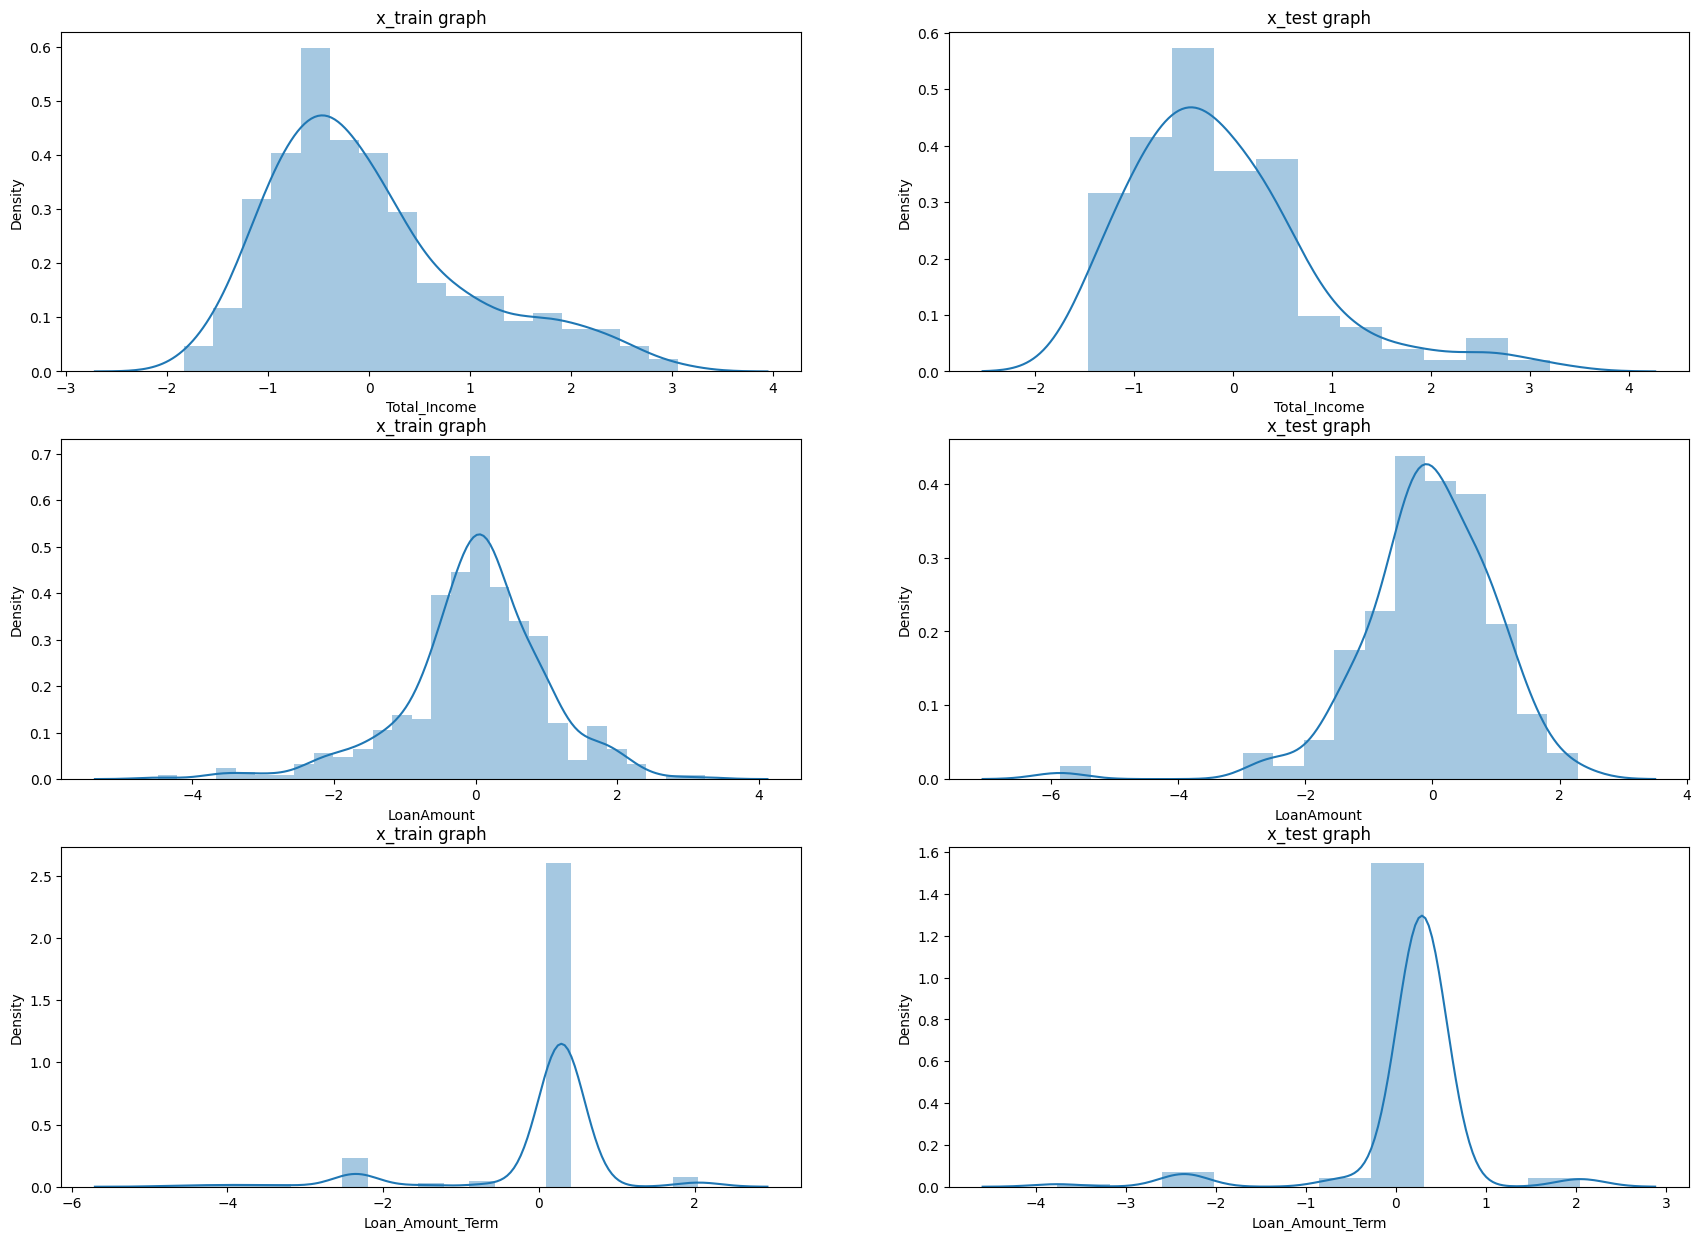

In [70]:
plt.figure(figsize=(21, 15))

# After Scaling 'x_train' for "Total_Income"
plt.subplot(3,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_train graph")
sns.distplot(x_train["Total_Income"])

# After Scaling 'x_test' for "Total_Income"
plt.subplot(3,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_test graph")
sns.distplot(x_test["Total_Income"])

# After Scaling 'x_train' for "LoanAmount"
plt.subplot(3,2,3) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_train graph")
sns.distplot(x_train["LoanAmount"])

# After Scaling 'x_test' for "Total_Income"
plt.subplot(3,2,4) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_test graph")
sns.distplot(x_test["LoanAmount"])

# After Scaling 'x_train' for "LoanAmount"
plt.subplot(3,2,5) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_train graph")
sns.distplot(x_train["Loan_Amount_Term"])

# After Scaling 'x_test' for "Total_Income"
plt.subplot(3,2,6) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("x_test graph")
sns.distplot(x_test["Loan_Amount_Term"])

plt.show()

In [71]:
# We see that the dataset has been scaled to values between 0 and 1, is now almost all 'Data points' have gathered around origin

#### NOTE: There is no change in the distribution pattern of the dataset. And there is no affect on outliers as well.

# V) Feature Selection Techniques
Feature Selection is:
1) selecting the columns which are imp for prediction, 
2) removing those columns which are not that imp, 
3) merging two columns as one (if needed), etc.

To do feature selection, one should have:
1) knowledge of that domain

## Other techniques
1) Forward Elimination (using MLxtend)
2) Backward Elimination (using MLxtend)

# VI) Model Selection